In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

In [6]:
hrdata = pd.read_csv('C:/Users/WoojaeYang/Desktop/DCR/data/WA_Fn-UseC_-HR-Employee-Attrition.csv')
hrdata.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [8]:
hrdata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [14]:
hrdata["event"] = hrdata["Attrition"].apply(lambda x: 1 if x == "Yes" else 0)  # 퇴사 여부를 1(이벤트 발생), 0(이벤트 없음)으로 변환
hrdata["duration"] = hrdata["YearsAtCompany"]  # 재직 기간을 생존 시간으로 사용

In [22]:
kmf = KaplanMeierFitter()
kmf.fit(hrdata['duration'], event_observed = hrdata['event'])

<lifelines.KaplanMeierFitter:"KM_estimate", fitted with 1470 total observations, 1233 right-censored observations>

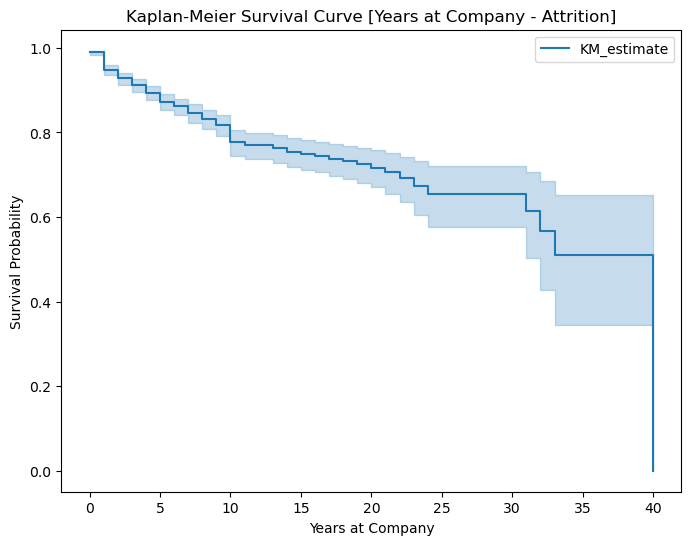

In [24]:
# 생존 곡선 시각화
plt.figure(figsize=(8,6))
kmf.plot_survival_function()
plt.title("Kaplan-Meier Survival Curve [Years at Company - Attrition]")
plt.xlabel("Years at Company")
plt.ylabel("Survival Probability")
plt.show()

In [26]:
hrdata['Department'].unique()

array(['Sales', 'Research & Development', 'Human Resources'], dtype=object)

In [32]:
df_sales = hrdata[hrdata['Department'] == 'Sales']
df_hr = hrdata[hrdata['Department'] == 'Human Resources']

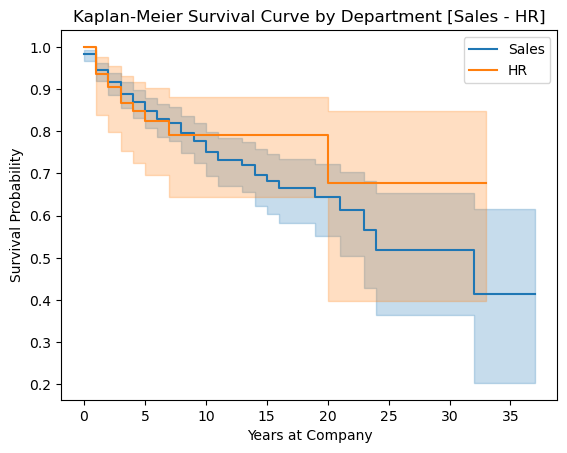

In [44]:
kmf1 = KaplanMeierFitter()
kmf2 = KaplanMeierFitter()

kmf1.fit(df_sales['duration'], event_observed = df_sales['event'], label="Sales")
kmf1.plot_survival_function()

kmf2.fit(df_hr['duration'], event_observed = df_hr['event'], label="HR")
kmf2.plot_survival_function()

plt.title("Kaplan-Meier Survival Curve by Department [Sales - HR]")
plt.xlabel("Years at Company")
plt.ylabel("Survival Probability")
plt.legend()
plt.show()

In [48]:
kmf1.confidence_interval_

,Sales_lower_0.95,Sales_upper_0.95
0.0,0.967361,0.992487
1.0,0.919489,0.963002
2.0,0.885187,0.938587
3.0,0.854622,0.915859
4.0,0.831681,0.898437
5.0,0.807246,0.879625
6.0,0.785684,0.863570
7.0,0.776370,0.856655
8.0,0.749162,0.836957
9.0,0.724253,0.819074


In [50]:
kmf2.confidence_interval_

,HR_lower_0.95,HR_upper_0.95
0.0,1.000000,1.000000
1.0,0.839618,0.975685
2.0,0.799125,0.955795
3.0,0.752895,0.931878
4.0,0.725945,0.917933
5.0,0.697018,0.902644
6.0,0.697018,0.902644
7.0,0.644523,0.882010
8.0,0.644523,0.882010
9.0,0.644523,0.882010
